## Week 6 Day 3
-	PCA: principal components, explained variance ratio, scree plot
-	Reduce MNIST from 784 dims to 50 check how much variance is retained
-	Project to 2D with PCA visualise digit clusters




1. Markdown: Concept what PCA does (finds directions of maximum variance), why (dimensionality reduction while preserving information), the math intuition (eigenvectors/eigenvalues of the covariance matrix, or SVD)


## 1. PCA (Principal Component Analysis)

**Idea:** Reduce the number of dimensions in your data while preserving as much information (variance) as possible.

**Core assumption:** variance = information. If data barely varies along some direction, that direction isn't distinguishing your points from each other it's not worth keeping. If data varies a lot along a direction, that direction carries meaningful signal.

**The question PCA answers:** given d original dimensions, what are the k directions (k < d) that preserve the most variance?



### Step 1 Center the data

```python
X_centered = X - X.mean(axis=0)
```

- Required because PCA finds directions of maximum *spread around a center*.
- Without centering, the first "principal component" would just point toward wherever the data happens to be offset from the origin, not the actual shape of the data.

------------------------------------------------------------


### Step 2 Covariance matrix

```python
cov_matrix = np.cov(X_centered, rowvar=False)
```

For d-dimensional data, this is a d×d matrix.
- **Diagonal** `Σ[i][i]` = variance of feature i alone
- **Off-diagonal** `Σ[i][j]` = covariance between features i and j, how much they move together

**Why off-diagonals matter:** large covariance (positive or negative) between two features means they're redundant much of their shared variance could be captured in fewer dimensions.
- High correlation = redundancy = compressibility. This redundancy is exactly what PCA exploits.

---

### Step 5  Scree plot

1. Plots eigenvalues (or cumulative explained variance) against component number.
2. Used to visually decide how many components (k) to keep look for the "elbow" where additional components stop adding much variance, similar in spirit to the elbow method in K-Means.

---

### Step 6 Project the data

To reduce from d to k dimensions, take the top k eigenvectors (as columns of a matrix `W`, shape d×k) and project:

### X_reduced = X_centered @ W

---

This gives you the data expressed in the new k-dimensional coordinate system defined by the top k principal components.

---

**Best when:** features are correlated/redundant, want to reduce dimensionality for visualization or speed, want to remove noise (low-variance dimensions often are noise)
**Struggles when:** relationships in data are highly non-linear (PCA only finds linear combinations), all dimensions carry roughly equal independent variance (nothing to compress), interpretability of components matters (PCs are linear combinations of original features, often hard to interpret directly)

2. From scratch, implement PCA using NumPy (covariance matrix →
- eigendecomposition → project onto top-k components), can see where "explained variance ratio" comes from mathematically




In [2]:
import numpy as np

def pca_from_scratch(X, n_components):
  #Step 1: Center the data
  X_centered =  X - X.mean(axis = 0)

  #Step 2: Compute covariance matrix
  cov_matrix = np.cov(X_centered, rowvar = False)

  #Step 3: eigendecomposition
  eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

  #Step 4: Sort  eigenvalues and corresponding eigenvectors descending
  idx = np.argsort(eigenvalues)[::-1]
  eigenvalues = eigenvalues[idx]
  eigenvectors = eigenvectors[:, idx]


  #STep 5: Select top n_components eigenvectors, project data onto them
  W = eigenvectors[:, :n_components]  # Keep all rows, first n_components columns
  X_reduced = X_centered @ W          #   matrix multiply: (n_samples, d) @ (d, n_components) = (n_samples, n_components)

  #Explained variance ratio: computed on all eigenvalues
  explained_variance_ratio = eigenvalues/ eigenvalues.sum()


  return X_reduced, explained_variance_ratio

### Step 3 Eigendecomposition

**Key theorem:** the principal components are the **eigenvectors** of the covariance matrix. The variance each captures is given by its corresponding **eigenvalue**.

- Eigenvectors are guaranteed **mutually orthogonal** because the covariance matrix is symmetric (spectral theorem), no need to enforce orthogonality manually, it falls out of the math.
- Sort eigenvalues descending: largest eigenvalue → PC1 (max variance direction), next largest → PC2 (max variance orthogonal to PC1), and so on.

```python
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# eigh (not eig) because cov_matrix is symmetric
# guarantees real eigenvalues, more numerically stable
# eigh returns ascending order, so reverse it:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
```

---

### Step 4 Explained variance ratio

1. explained_variance_ratio_i = eigenvalue_i / sum(all eigenvalues)
2. cumulative_variance(k) = sum(top k eigenvalues) / sum(all eigenvalues)




- Sum of all eigenvalues = sum of all diagonal variances (trace of covariance matrix) = total variance in the data.

- Dividing by this total tells you what fraction of the original information each component (or group of components) retains.

**Example:** eigenvalues `[8, 1.5, 0.5]` → total = 10 → PC1 alone = 80%, PC1+PC2 = 95%.

In [3]:
from sklearn.datasets import make_blobs

X_small, _ = make_blobs(n_samples=30, centers=3, n_features=4, random_state=42)

4. sklearn version: sklearn.decomposition.PCA, compare results to your scratch version

In [4]:
X_reduced, var_ratio = pca_from_scratch(X_small, n_components=2)
print(X_reduced.shape)
print(var_ratio)

(30, 2)
[0.71347457 0.27057956 0.00884576 0.00710011]


In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_mnist = mnist.data

In [7]:
X_mnist.shape

(70000, 784)

In [8]:
X_subset = X_mnist[:1000]

# your scratch version
X_reduced_scratch, var_ratio_scratch = pca_from_scratch(X_subset, n_components=50)

# sklearn version
from sklearn.decomposition import PCA
pca_sklearn = PCA(n_components=50)
X_reduced_sklearn = pca_sklearn.fit_transform(X_subset)

print("Scratch explained variance (top 5):", var_ratio_scratch[:5])
print("Sklearn explained variance (top 5):", pca_sklearn.explained_variance_ratio_[:5])

Scratch explained variance (top 5): [0.09931776 0.07755832 0.06838248 0.05425498 0.04871299]
Sklearn explained variance (top 5): [0.09931776 0.07755832 0.06838248 0.05425498 0.04871299]


5. Applied to MNIST --> reduce 784→50 dims, check cumulative explained variance retained

In [11]:
pca_full = PCA(n_components=50)
X_mnist_reduced = pca_full.fit_transform(X_mnist)

total_variance_retained = pca_full.explained_variance_ratio_.sum()
print(f"Variance retained with 50 components: {total_variance_retained:.4f}")

Variance retained with 50 components: 0.8254






6. 2D projection + visualization: project to 2 components, scatter plot colored by digit label, see how well-separated the digit clusters are

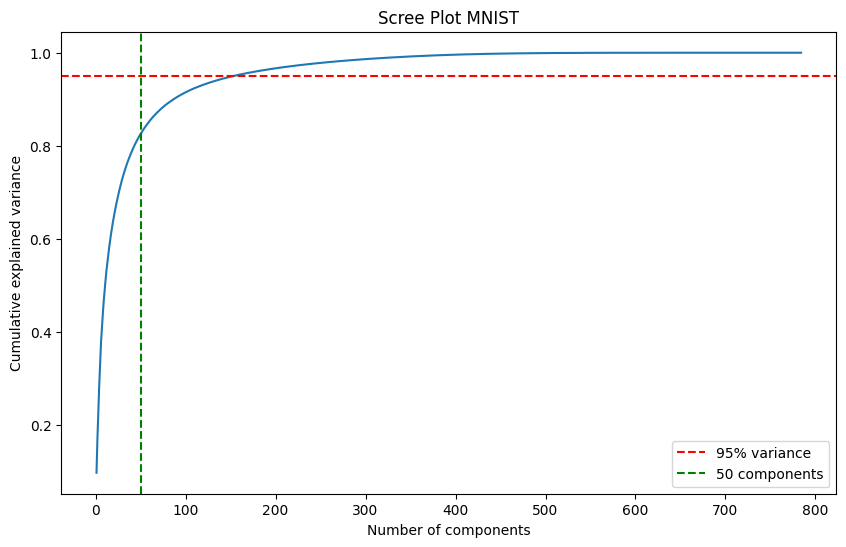

Components needed for 95% variance: 154


In [14]:
import matplotlib.pyplot as plt


pca_full_784 = PCA(n_components=784)
pca_full_784.fit(X_mnist)


cumulative_variance = np.cumsum(pca_full_784.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 785), cumulative_variance)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=50, color='g', linestyle='--', label='50 components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Scree Plot MNIST')
plt.legend()
plt.show()


# find exact number of components needed for 95%
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

project to 2D and visualize the actual digit clusters

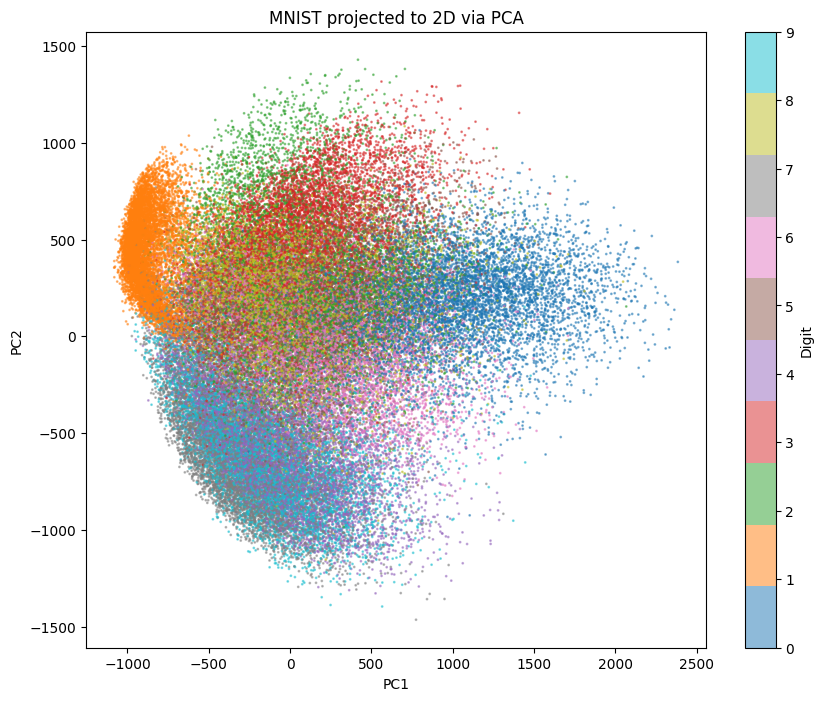

In [15]:
pca_2d = PCA(n_components=2)
X_mnist_2d = pca_2d.fit_transform(X_mnist)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_mnist_2d[:, 0], X_mnist_2d[:, 1], c=mnist.target.astype(int), cmap='tab10', s=1, alpha=0.5)
plt.colorbar(scatter, label='Digit')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('MNIST projected to 2D via PCA')
plt.show()

## PCA — Decision Guide entry

| Method | Best when... | Struggles when... |
|---|---|---|
| **PCA** | Features are correlated/redundant, need dimensionality reduction for speed/visualization/noise removal | Relationships are non-linear, all dimensions carry independent variance, need interpretable components |